# Single Atom Calculation

In [1]:
# Uncomment the next line if you have ipympl installed and want interactive plots
# %matplotlib widget

import matplotlib.pyplot as plt
import numpy as np

import pairinteraction.real as pi
from pairinteraction.visualization.colormaps import alphamagma

## Parameters

In [2]:
steps = 50
distance = np.linspace(1.0, 10.0, steps)
angle = np.linspace(0.0, 0.0, steps)

## Atom 1

In [3]:
ket1 = pi.KetAtom("Rb", n=60, l=0, j=0.5, m=0.5)
print(f"State of interest 1: {ket1}")

basis1 = pi.BasisAtom(ket1.species, n=(58, 62), l=(-2, 2))
print(str(basis1))
print(f" ⇒ Basis 1 consists of {basis1.number_of_kets} kets")

system1 = pi.SystemAtom(basis1)
system1.set_electric_field([0.0, 0.0, 0.0], unit="V/cm")
system1.set_magnetic_field([0.0, 0.0, 0.0], unit="G")
system1.set_diamagnetism_enabled(True)

State of interest 1: |Rb:60,S_1/2,1/2⟩
BasisAtomReal(n=(58, 62), l=(-2, 2))
 ⇒ Basis 1 consists of 90 kets


SystemAtomReal(BasisAtomReal(n=(58, 62), l=(-2, 2)), is_diagonal=True)

## Atom 2

In [4]:
ket2 = pi.KetAtom("Rb", n=60, l=0, j=0.5, m=0.5)
print(f"State of interest 2: {ket2}")

basis2 = pi.BasisAtom(ket2.species, n=(58, 62), l=(-2, 2))
print(str(basis2))
print(f" ⇒ Basis 2 consists of {basis2.number_of_kets} kets")

system2 = pi.SystemAtom(basis2)
system2.set_electric_field([0.0, 0.0, 0.0], unit="V/cm")
system2.set_magnetic_field([0.0, 0.0, 0.0], unit="G")
system2.set_diamagnetism_enabled(True)

State of interest 2: |Rb:60,S_1/2,1/2⟩
BasisAtomReal(n=(58, 62), l=(-2, 2))
 ⇒ Basis 2 consists of 90 kets


SystemAtomReal(BasisAtomReal(n=(58, 62), l=(-2, 2)), is_diagonal=True)

## Pair Basis

In [5]:
pi.diagonalize([system1, system2], diagonalizer="lapacke_evr", float_type="float32")
pair_energy = sum(system.get_corresponding_energy(ket, "GHz") for ket, system in zip([ket1, ket2], [system1, system2]))

basis_pair = pi.BasisPair(
    [system1, system2],
    energy=(pair_energy - 3.0, pair_energy + 3.0),
    energy_unit="GHz",
    m=(1.0, 1.0),
)
print(str(basis_pair))
print(f" ⇒ Basis Pair consists of {basis_pair.number_of_kets} kets")

BasisPairReal(|Rb:59,S_1/2,1/2; Rb:61,S_1/2,1/2⟩ ... |Rb:61,S_1/2,1/2; Rb:59,S_1/2,1/2⟩)
 ⇒ Basis Pair consists of 19 kets


## Pair System

In [6]:
system_pair_list = []

for i in range(steps):
    system_pair = pi.SystemPair(basis_pair)
    system_pair.set_distance(distance[i], angle[i], unit="micrometer")
    system_pair.set_interaction_order(3)
    system_pair_list.append(system_pair)

pi.diagonalize(system_pair_list, diagonalizer="lapacke_evr", float_type="float32")

In [7]:
energies_list = [system.get_eigenenergies(unit="GHz") - pair_energy for system in system_pair_list]
overlaps_list = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pair_list]

## Plot

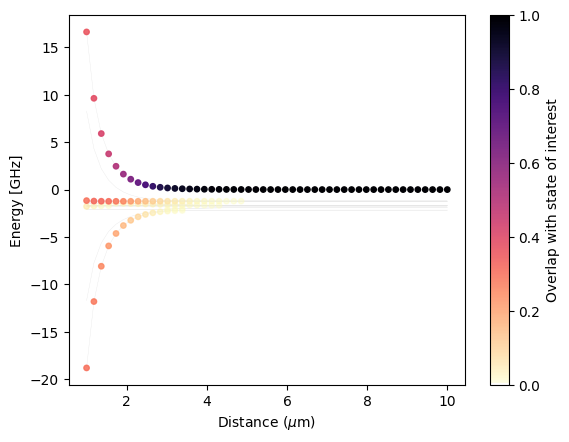

In [8]:
fig, ax = plt.subplots()

ax.set_xlabel(r"Distance ($\mu$m)")
ax.set_ylabel("Energy [GHz]")

if len({len(es) for es in energies_list}) <= 1:  # check if homogeneous shape
    ax.plot(distance, np.array(energies_list), c="0.9", lw=0.25, zorder=-10)
else:
    for x, es in zip(distance, energies_list):
        ax.plot([x] * len(es), es, c="0.9", ls="None", marker=".", zorder=-10)

x_repeated = np.hstack([val * np.ones_like(es) for val, es in zip(distance, energies_list)])
energies_flattened = np.hstack(energies_list)
overlaps_flattened = np.hstack(overlaps_list)
sorter = np.argsort(overlaps_flattened)

scat = ax.scatter(
    x_repeated[sorter],
    energies_flattened[sorter],
    c=overlaps_flattened[sorter],
    s=15,
    vmin=0,
    vmax=1,
    cmap=alphamagma
)

fig.colorbar(scat, ax=ax, label="Overlap with state of interest")

plt.show()